In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier



df = pd.read_csv('winequality-red.csv', delimiter=';')

df.info()
df.dropna(inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1598 non-null   float64
 1   volatile acidity      1598 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1598 non-null   float64
 4   chlorides             1598 non-null   float64
 5   free sulfur dioxide   1598 non-null   float64
 6   total sulfur dioxide  1598 non-null   float64
 7   density               1598 non-null   float64
 8   pH                    1598 non-null   float64
 9   sulphates             1598 non-null   float64
 10  alcohol               1598 non-null   float64
 11  quality               1598 non-null   float64
dtypes: float64(12)
memory usage: 150.0 KB


In [31]:
imputer = KNNImputer(n_neighbors=2)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_numerical = df[numerical_cols]
df_imputed = imputer.fit_transform(df_numerical)
df_imputed

'''

'''
# imputer = KNNImputer(n_neighbors=2)
# df_imputed = imputer.fit_transform(df)
# df_imputed = pd.DataFrame(df_imputed, columns=df.columns)
# df_imputed.isnull().sum()
# df_imputed.to_csv("winequality-red-imputed.csv", index=False)

array([[ 7.8  ,  0.88 ,  0.   , ...,  0.68 ,  9.8  ,  5.   ],
       [ 7.8  ,  0.76 ,  0.04 , ...,  0.65 ,  9.8  ,  5.   ],
       [11.2  ,  0.28 ,  0.56 , ...,  0.58 ,  9.8  ,  6.   ],
       ...,
       [ 5.9  ,  0.55 ,  0.1  , ...,  0.76 , 11.2  ,  6.   ],
       [ 6.3  ,  0.51 ,  0.13 , ...,  0.75 , 11.   ,  6.   ],
       [ 5.9  ,  0.645,  0.12 , ...,  0.71 , 10.2  ,  5.   ]])

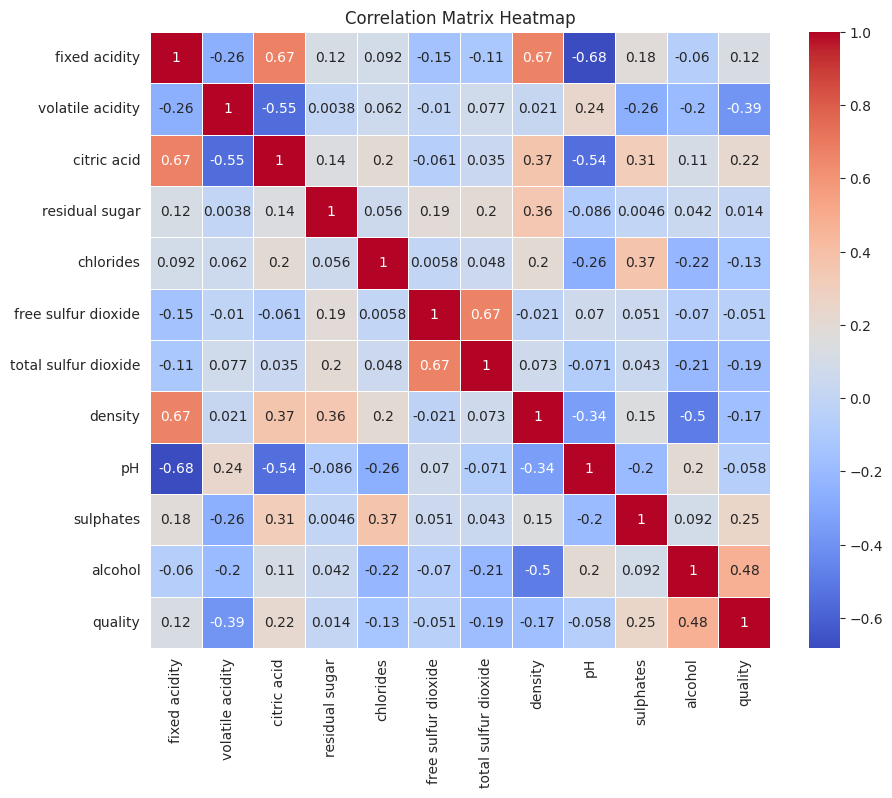

In [32]:
# Correlation 

'''
   Here We check the relationship between all features and the target feature (Quality)
   And from the plot we can notice that quality has a moderate relations with 



'''
correlation_matrix = df.corr()

# Create a heatmap for the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [29]:
# Define features (X) and target (y)
X = df.drop(columns=['quality'])  # Features: All columns except 'quality'
y = df['quality']                 # Target: 'quality'

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Use SelectKBest to select top 5 features based on f_regression
selector = SelectKBest(score_func=f_classif, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Train a RandomForestClassifier on the selected features
model = RandomForestClassifier(random_state=42)
model.fit(X_train_selected, y_train)

# Predict and evaluate performance using Mean Squared Error (MSE)
y_pred = model.predict(X_test_selected)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error with selected features: {mse:.4f}")

# Get the selected feature names
selected_features = X.columns[selector.get_support()]
print("\nSelected Features classification:\n", selected_features)

Mean Squared Error with selected features: 0.4717

Selected Features classification:
 Index(['volatile acidity', 'total sulfur dioxide', 'alcohol'], dtype='object')


In [30]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Use SelectKBest to select top 5 features based on f_regression
selector = SelectKBest(score_func=f_regression, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Train a RandomForestRegressor on the selected features
model = RandomForestRegressor(random_state=42)
model.fit(X_train_selected, y_train)

# Predict and evaluate performance using Mean Squared Error (MSE)
y_pred = model.predict(X_test_selected)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error with selected features: {mse:.4f}")

# Get the selected feature names
selected_features = X.columns[selector.get_support()]
print("\nSelected Features regression:\n", selected_features)

Mean Squared Error with selected features: 0.3757

Selected Features regression:
 Index(['volatile acidity', 'sulphates', 'alcohol'], dtype='object')
